In [1]:
import os
import sys
import copy
import json
import time
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pyro

sys.path.append('../..')
import sherlock as slk

%load_ext autoreload
%autoreload 2

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Adjust `SEARCH_TRIALS`, `NUM_EPOCHS`, `VALIDATE_EVERY`, and `RESULTS_DIR` below.

Each trial is a dict of keyword arguments passed to `slk.tl.run()`.  
Parameters not specified fall back to the defaults in `run()`.

**Key parameters:**
| param | effect |
|---|---|
| `lr` | Adam learning rate — too high → noisy ELBO, too low → slow convergence |
| `l0_lambda` | L0 sparsity weight — higher → more gates pruned to 0 |
| `ce_lambda` | Cross-entropy classifier weight — higher → better perturbation identity in z |
| `cov_lambda` | Covariance low-rank ridge — higher → smaller Σ_P entries |
| `gate_row_repulsion_lambda` | Encourages perturbations to use different latent dims |
| `n_epochs_kl_warmup` | Epochs to ramp KL 0→1; L0 ramps in over the *next* warmup window |
| `tau_end` | Final gate temperature — lower → harder binary gates |
| `ntc_lambda` | NTC reconstruction weight |
| `pert_lambda` | Perturbed-cell reconstruction weight |

In [2]:
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_EPOCHS     = 500
VALIDATE_EVERY = 20       # check ATE every N epochs — lower = finer trajectory
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 30       # ELBO early stopping patience
RESULTS_DIR    = 'results/hparam_search'

os.makedirs(f'{RESULTS_DIR}/figures', exist_ok=True)

# ── Search trials ─────────────────────────────────────────────────────────────
# Each dict is passed as **kwargs to slk.tl.run().  Add/remove/modify as needed.
# The 'name' key is only used for labelling results — not forwarded to run().

SEARCH_TRIALS = [
    # ── baseline (matches reproducibility notebook defaults) ──────────────────
    dict(name='baseline'),
    # dict(name='baseline',      lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),

    # gate_row_repulsion_lambda sweep (default 1e-3)
    # dict(name='gate_repulsion_0',    gate_row_repulsion_lambda=0.0 ),
    dict(name='gate_repulsion_1e-4', gate_row_repulsion_lambda=1e-4),
    dict(name='gate_repulsion_1e-3', gate_row_repulsion_lambda=1e-3),
    dict(name='gate_repulsion_1e-2', gate_row_repulsion_lambda=1e-2),
    dict(name='gate_repulsion_1e-1', gate_row_repulsion_lambda=1e-1),

    # H_lambda sweep (default 1e-3)
    dict(name='H_lambda_0',    H_lambda=0.0 ),
    dict(name='H_lambda_1e-4', H_lambda=1e-4),
    dict(name='H_lambda_1e-3', H_lambda=1e-3),
    dict(name='H_lambda_1e-2', H_lambda=1e-2),
    dict(name='H_lambda_1e-1', H_lambda=1e-1),

    # cov_lambda sweep (default 1e-4)
    dict(name='cov_lambda_0',    cov_lambda=0.0 ),
    dict(name='cov_lambda_1e-5', cov_lambda=1e-5),
    dict(name='cov_lambda_1e-4', cov_lambda=1e-4),
    dict(name='cov_lambda_1e-3', cov_lambda=1e-3),
    dict(name='cov_lambda_1e-2', cov_lambda=1e-2),


    # # ── lr sweep ──────────────────────────────────────────────────────────────
    # dict(name='lr_5e-4',       lr=5e-4,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),
    # dict(name='lr_2e-3',       lr=2e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),

    # # ── l0_lambda sweep ───────────────────────────────────────────────────────
    # dict(name='l0_0.3',        lr=1e-3,  l0_lambda=0.3, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),
    # dict(name='l0_0.5',        lr=1e-3,  l0_lambda=0.5, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),
    # dict(name='l0_1.5',        lr=1e-3,  l0_lambda=1.5, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),

    # # ── ce_lambda sweep ───────────────────────────────────────────────────────
    # dict(name='ce_5',          lr=1e-3,  l0_lambda=1.0, ce_lambda=5,  cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),
    # dict(name='ce_20',         lr=1e-3,  l0_lambda=1.0, ce_lambda=20, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),

    # # ── cov_lambda sweep ──────────────────────────────────────────────────────
    # dict(name='cov_0',         lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=0,    gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),
    # dict(name='cov_1e-3',      lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-3, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.3),

    # # ── gate repulsion sweep ──────────────────────────────────────────────────
    # dict(name='rep_0',         lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=0,    n_epochs_kl_warmup=50,  tau_end=0.3),
    # dict(name='rep_1e-2',      lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-2, n_epochs_kl_warmup=50,  tau_end=0.3),

    # # ── KL warmup length sweep (longer = gentler L0 intro) ────────────────────
    # dict(name='warmup_75',     lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=75,  tau_end=0.3),
    # dict(name='warmup_100',    lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=100, tau_end=0.3),

    # # ── tau_end sweep (lower = harder binary gates) ───────────────────────────
    # dict(name='tau_0.1',       lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.1),
    # dict(name='tau_0.5',       lr=1e-3,  l0_lambda=1.0, ce_lambda=10, cov_lambda=1e-4, gate_row_repulsion_lambda=1e-3, n_epochs_kl_warmup=50,  tau_end=0.5),
]

print(f'Device: {DEVICE}  |  Trials: {len(SEARCH_TRIALS)}  |  Epochs/trial: {NUM_EPOCHS}')
print(f'Results dir: {RESULTS_DIR}')

Device: cuda  |  Trials: 15  |  Epochs/trial: 500
Results dir: results/hparam_search


## Data loading

In [3]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)

print(f'Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs["pert"].nunique()}')

100%|██████████| 681/681 [00:08<00:00, 79.00it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Run trials

Each trial trains from scratch with a fixed seed so runs are comparable.
Final ATE is computed via `model.predict_counterfactual_effects()` after training.


Trial 1/15: baseline
  Params: {}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:56<00:00,  2.27s/it, ATE=0.4316, CE=3.9721, ELBO=1824.5603, KLw=1.00, R2_ntc=0.9656, R2_p=0.9618, acc=0.204, pi25=0.01, pi99=1.00, tau=0.300] 


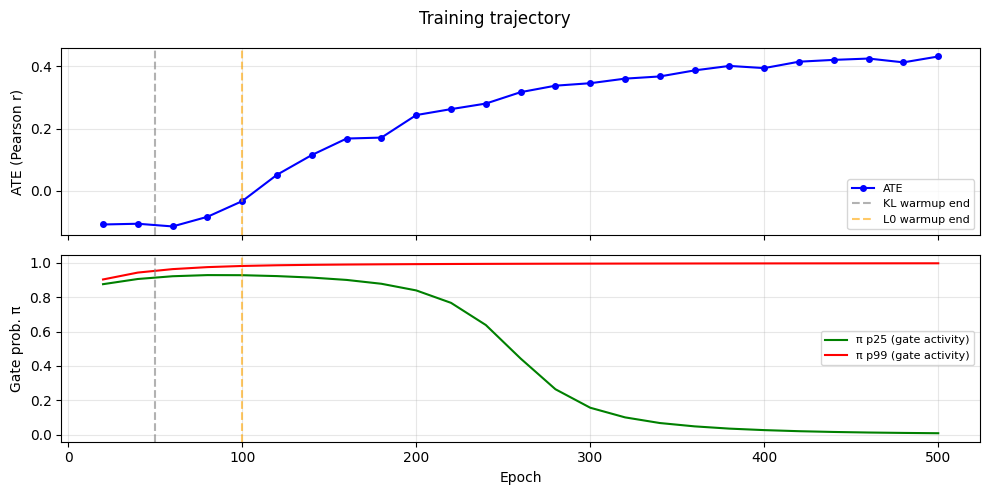

  → ATE=0.4201  gate_dead=41.02%  t=1138s

Trial 2/15: gate_repulsion_1e-4
  Params: {'gate_row_repulsion_lambda': 0.0001}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:56<00:00,  2.27s/it, ATE=0.4062, CE=4.0531, ELBO=1824.3658, KLw=1.00, R2_ntc=0.9676, R2_p=0.9621, acc=0.192, pi25=0.01, pi99=1.00, tau=0.300]


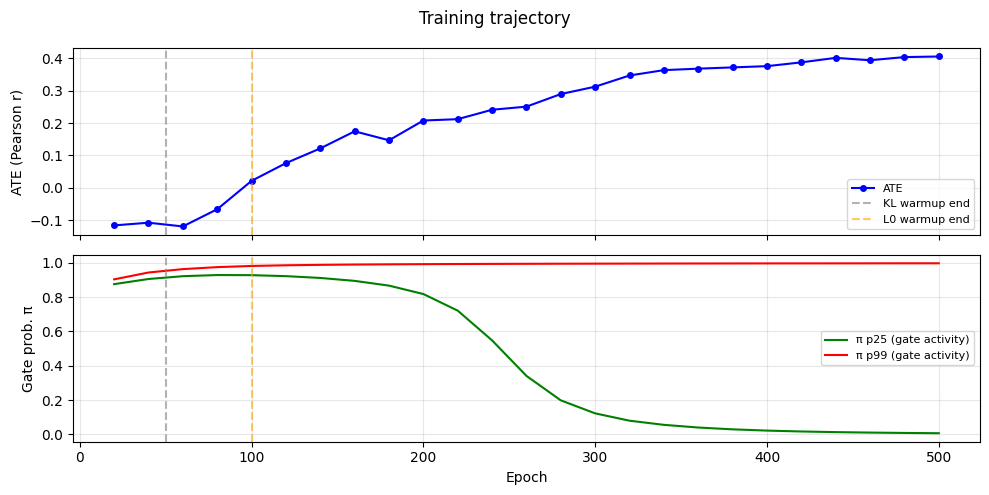

  → ATE=0.4094  gate_dead=43.46%  t=1137s

Trial 3/15: gate_repulsion_1e-3
  Params: {'gate_row_repulsion_lambda': 0.001}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:53<00:00,  2.27s/it, ATE=0.3865, CE=3.9670, ELBO=1823.7093, KLw=1.00, R2_ntc=0.9688, R2_p=0.9620, acc=0.206, pi25=0.01, pi99=1.00, tau=0.300]


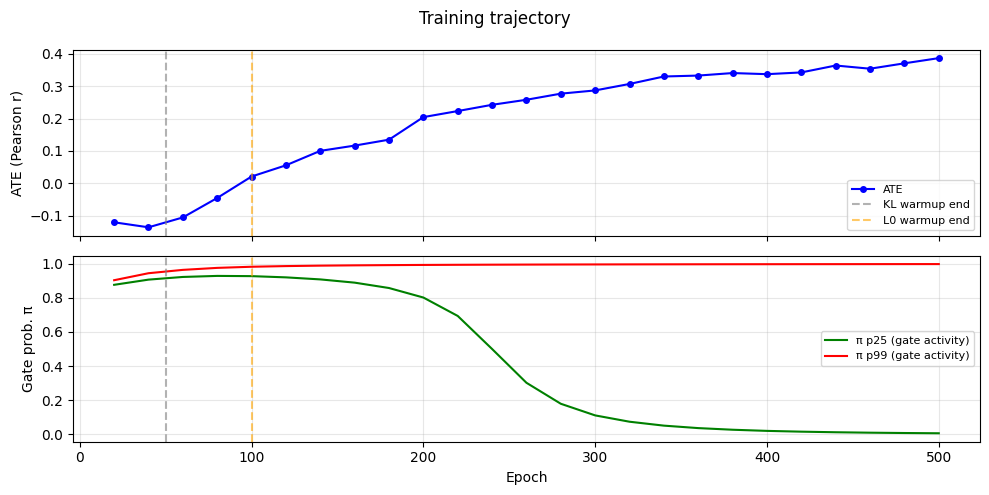

  → ATE=0.3865  gate_dead=42.62%  t=1135s

Trial 4/15: gate_repulsion_1e-2
  Params: {'gate_row_repulsion_lambda': 0.01}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:52<00:00,  2.26s/it, ATE=0.4433, CE=3.9685, ELBO=1824.0430, KLw=1.00, R2_ntc=0.9671, R2_p=0.9621, acc=0.204, pi25=0.01, pi99=1.00, tau=0.300]


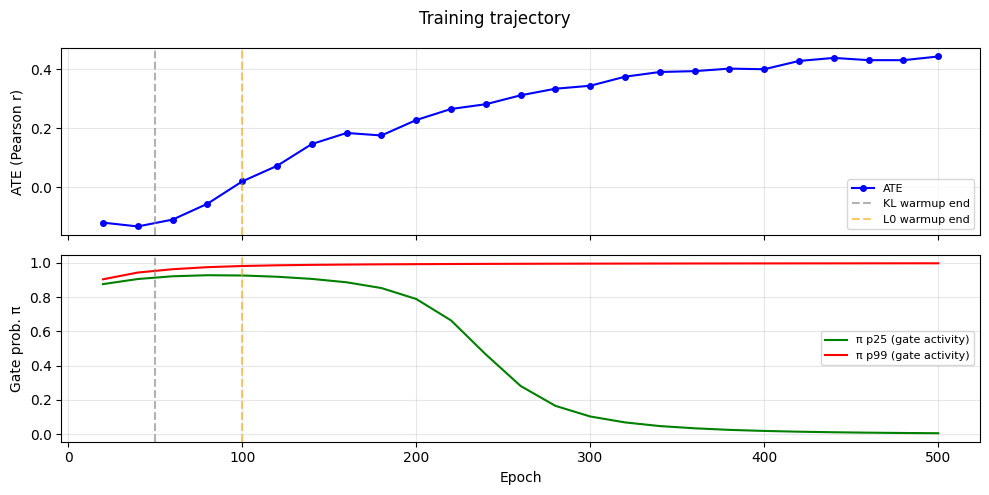

  → ATE=0.4433  gate_dead=43.78%  t=1133s

Trial 5/15: gate_repulsion_1e-1
  Params: {'gate_row_repulsion_lambda': 0.1}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:45<00:00,  2.25s/it, ATE=0.4304, CE=3.9660, ELBO=1823.7316, KLw=1.00, R2_ntc=0.9676, R2_p=0.9625, acc=0.203, pi25=0.01, pi99=1.00, tau=0.300]


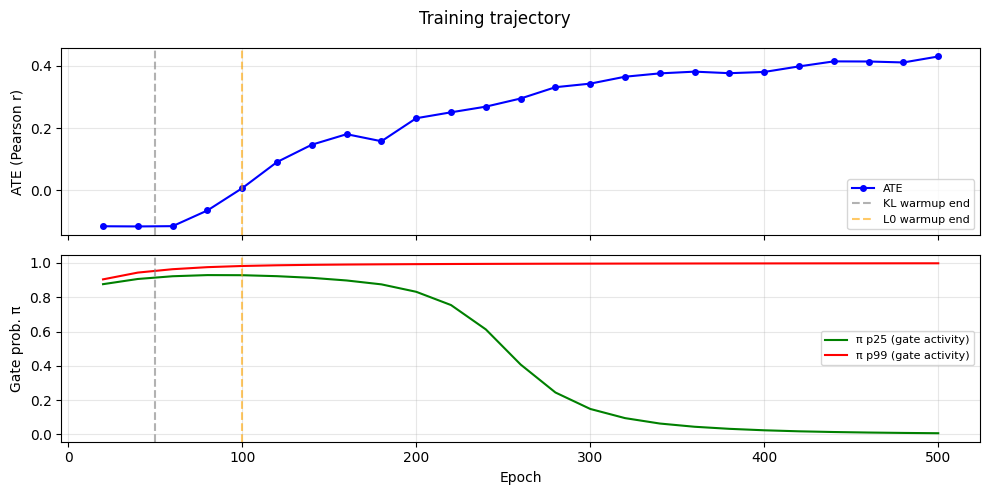

  → ATE=0.4086  gate_dead=41.91%  t=1126s

Trial 6/15: H_lambda_0
  Params: {'H_lambda': 0.0}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:38<00:00,  2.24s/it, ATE=0.4753, CE=4.0153, ELBO=1823.5042, KLw=1.00, R2_ntc=0.9676, R2_p=0.9638, acc=0.196, pi25=0.01, pi99=1.00, tau=0.300]


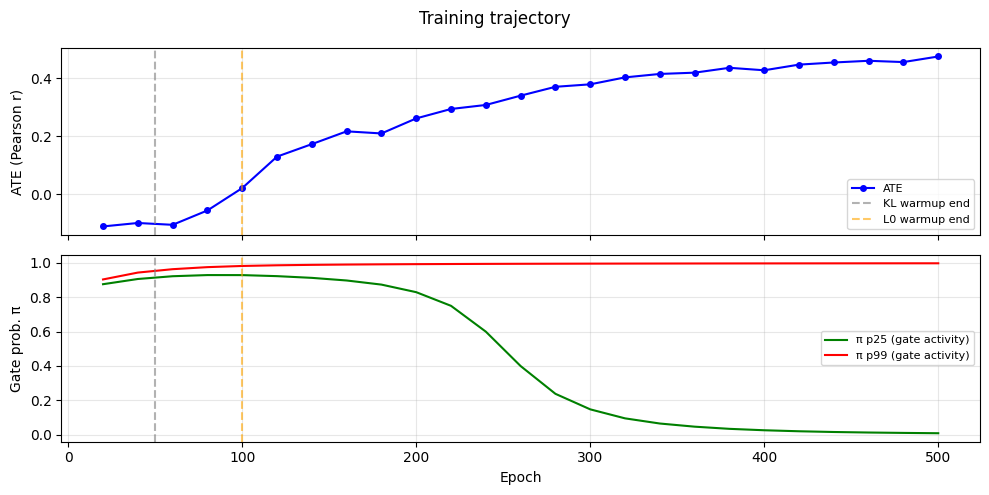

  → ATE=0.4753  gate_dead=41.58%  t=1119s

Trial 7/15: H_lambda_1e-4
  Params: {'H_lambda': 0.0001}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:39<00:00,  2.24s/it, ATE=0.4229, CE=3.9727, ELBO=1823.3393, KLw=1.00, R2_ntc=0.9662, R2_p=0.9635, acc=0.204, pi25=0.01, pi99=1.00, tau=0.300] 


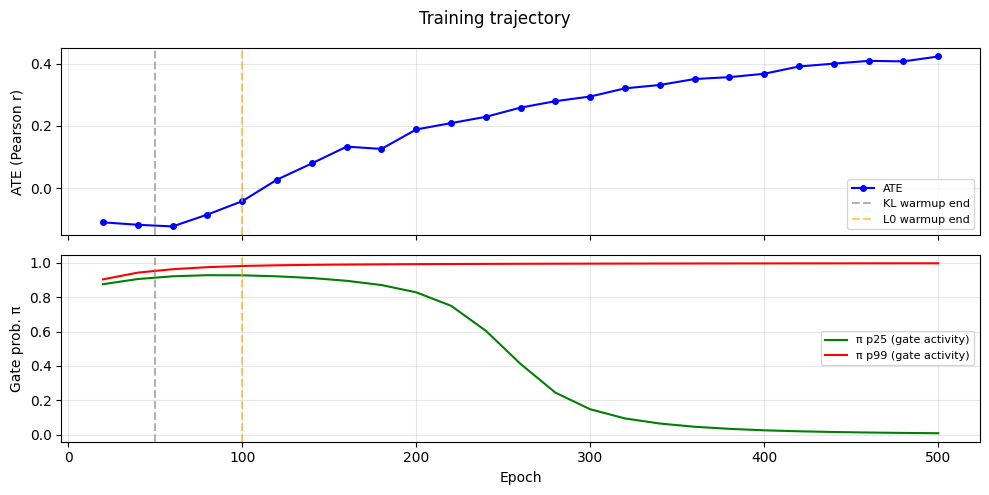

  → ATE=0.4229  gate_dead=41.35%  t=1121s

Trial 8/15: H_lambda_1e-3
  Params: {'H_lambda': 0.001}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:41<00:00,  2.24s/it, ATE=0.4385, CE=4.0007, ELBO=1824.5904, KLw=1.00, R2_ntc=0.9674, R2_p=0.9623, acc=0.201, pi25=0.01, pi99=1.00, tau=0.300]


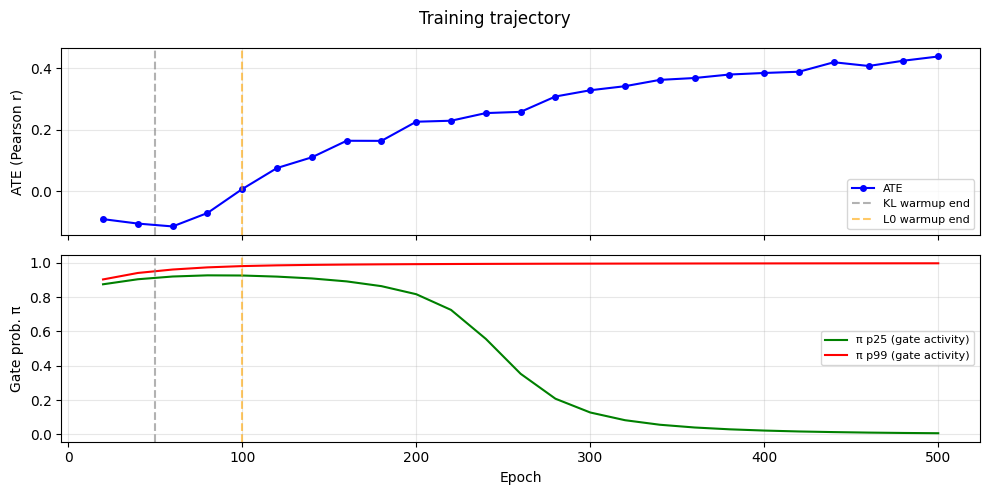

  → ATE=0.4323  gate_dead=43.35%  t=1123s

Trial 9/15: H_lambda_1e-2
  Params: {'H_lambda': 0.01}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:40<00:00,  2.24s/it, ATE=0.4484, CE=3.9636, ELBO=1823.5809, KLw=1.00, R2_ntc=0.9676, R2_p=0.9624, acc=0.204, pi25=0.01, pi99=1.00, tau=0.300]


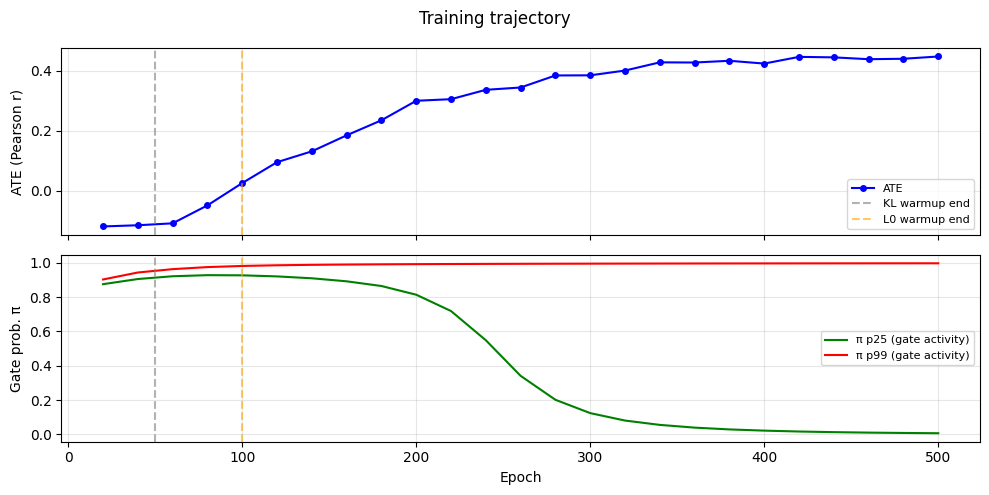

  → ATE=0.4332  gate_dead=41.75%  t=1122s

Trial 10/15: H_lambda_1e-1
  Params: {'H_lambda': 0.1}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:36<00:00,  2.23s/it, ATE=0.4773, CE=3.9539, ELBO=1823.1995, KLw=1.00, R2_ntc=0.9674, R2_p=0.9631, acc=0.206, pi25=0.01, pi99=1.00, tau=0.300] 


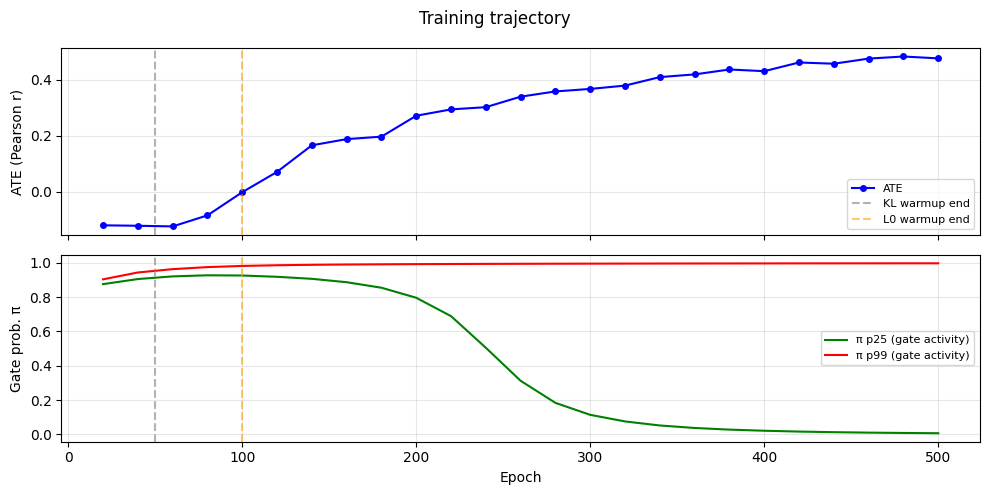

  → ATE=0.4812  gate_dead=42.92%  t=1118s

Trial 11/15: cov_lambda_0
  Params: {'cov_lambda': 0.0}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:41<00:00,  2.24s/it, ATE=0.3845, CE=4.0021, ELBO=1825.0475, KLw=1.00, R2_ntc=0.9668, R2_p=0.9613, acc=0.201, pi25=0.01, pi99=1.00, tau=0.300] 


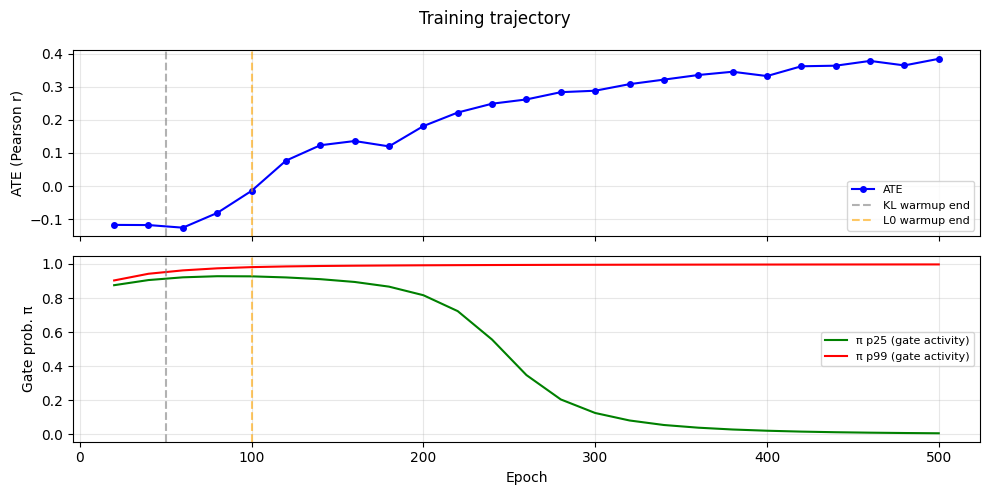

  → ATE=0.3754  gate_dead=43.48%  t=1123s

Trial 12/15: cov_lambda_1e-5
  Params: {'cov_lambda': 1e-05}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:32<00:00,  2.22s/it, ATE=0.4585, CE=4.0615, ELBO=1824.0309, KLw=1.00, R2_ntc=0.9669, R2_p=0.9609, acc=0.189, pi25=0.01, pi99=1.00, tau=0.300] 


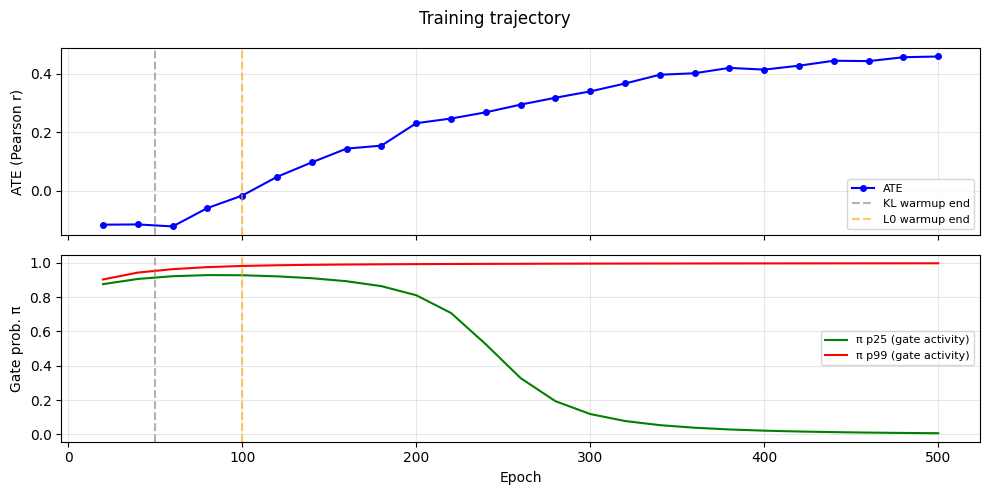

  → ATE=0.4549  gate_dead=43.77%  t=1114s

Trial 13/15: cov_lambda_1e-4
  Params: {'cov_lambda': 0.0001}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:26<00:00,  2.21s/it, ATE=0.4343, CE=3.9616, ELBO=1823.1345, KLw=1.00, R2_ntc=0.9676, R2_p=0.9632, acc=0.206, pi25=0.01, pi99=1.00, tau=0.300] 


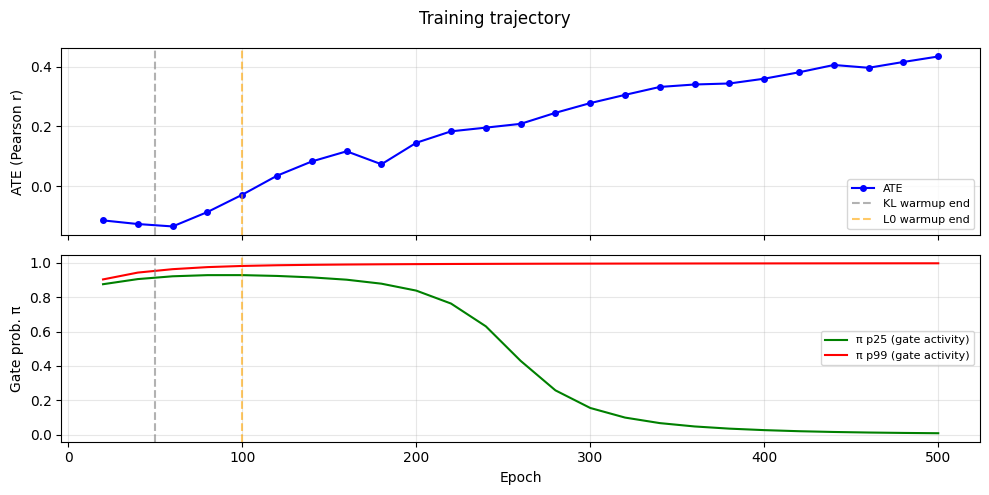

  → ATE=0.4094  gate_dead=40.46%  t=1108s

Trial 14/15: cov_lambda_1e-3
  Params: {'cov_lambda': 0.001}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:29<00:00,  2.22s/it, ATE=0.3898, CE=3.9589, ELBO=1823.0964, KLw=1.00, R2_ntc=0.9684, R2_p=0.9622, acc=0.206, pi25=0.01, pi99=1.00, tau=0.300] 


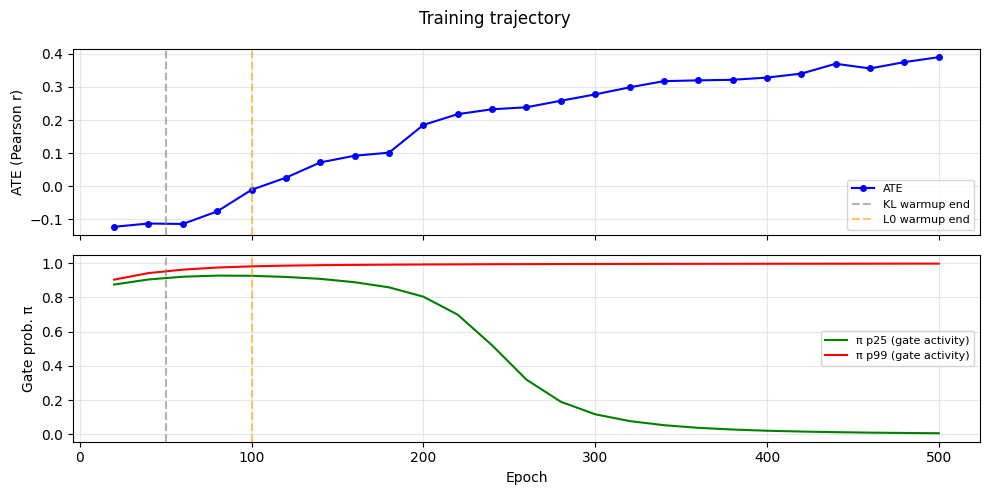

  → ATE=0.3898  gate_dead=42.10%  t=1110s

Trial 15/15: cov_lambda_1e-2
  Params: {'cov_lambda': 0.01}
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [18:26<00:00,  2.21s/it, ATE=0.4613, CE=4.0128, ELBO=1824.5985, KLw=1.00, R2_ntc=0.9677, R2_p=0.9624, acc=0.198, pi25=0.01, pi99=1.00, tau=0.300]


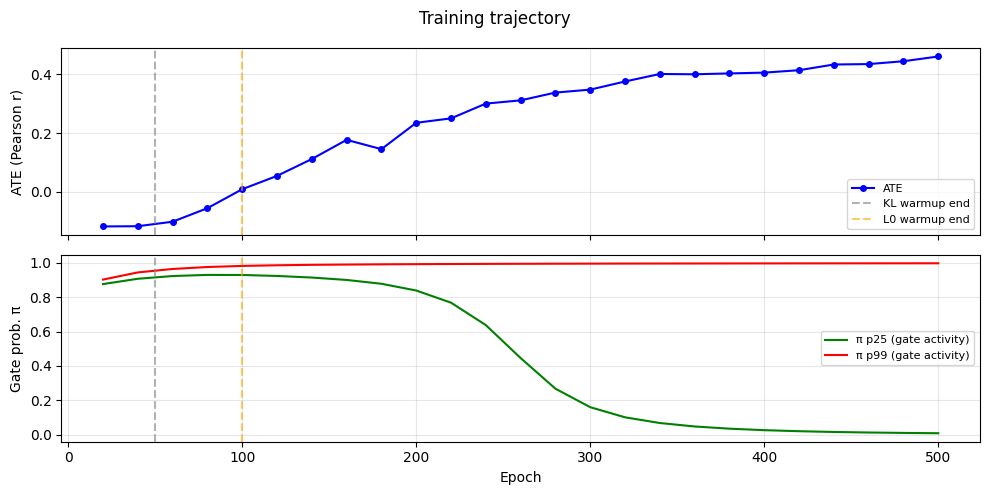

  → ATE=0.4526  gate_dead=38.95%  t=1108s

All trials complete.  Best ATE: 0.4812 (H_lambda_1e-1)


In [4]:
all_results = []

for trial_idx, trial in enumerate(SEARCH_TRIALS):
    trial_name = trial.pop('name', f'trial_{trial_idx}')
    kwargs = {**trial}

    print(f'\n{"="*60}')
    print(f'Trial {trial_idx+1}/{len(SEARCH_TRIALS)}: {trial_name}')
    print(f'  Params: {kwargs}')
    print('='*60)

    t0 = time.time()
    try:
        out = slk.tl.run(
            data,
            model='vae',
            batch_size=BATCH_SIZE,
            num_epochs=NUM_EPOCHS,
            validate_every=VALIDATE_EVERY,
            device=DEVICE,
            latent_dim=LATENT_DIM,
            patience=PATIENCE,
            seed=0,
            debug=True,
            **kwargs,
        )
        model = out['model']
        elapsed = time.time() - t0

        # Compute final ATE with full centroid resolution
        ate_out = model.predict_counterfactual_effects(
            data,
            n_centroids=25,
            observed_effect=data.uns['treat_effect'],
            device=DEVICE,
        )
        final_ate = float(ate_out.get('corr', float('nan')))

        # Gate sparsity snapshot
        pi = model.gate.expected_L0().detach().flatten().cpu().numpy()
        pi25 = float(np.percentile(pi, 25))
        pi75 = float(np.percentile(pi, 75))
        pi99 = float(np.percentile(pi, 99))
        frac_dead = float((pi < 0.05).mean())  # fraction of gates collapsed

        record = {
            'name': trial_name,
            'ATE': final_ate,
            'elapsed_s': elapsed,
            'pi25': pi25, 'pi75': pi75, 'pi99': pi99,
            'frac_gates_dead': frac_dead,
            **kwargs,
        }
        all_results.append(record)
        print(f'  → ATE={final_ate:.4f}  gate_dead={frac_dead:.2%}  t={elapsed:.0f}s')

        # Save model
        # slk.tl.save_results(out, path=f'{RESULTS_DIR}/{trial_name}')

    except Exception as e:
        elapsed = time.time() - t0
        print(f'  ✗ FAILED after {elapsed:.0f}s: {e}')
        all_results.append({'name': trial_name, 'ATE': float('nan'), 'elapsed_s': elapsed, **kwargs})
    finally:
        # Restore the trial 'name' key in case the cell is re-run
        trial['name'] = trial_name

results_df = pd.DataFrame(all_results).sort_values('ATE', ascending=False).reset_index(drop=True)
# results_df.to_csv(f'{RESULTS_DIR}/search_results.csv', index=False)

print(f'\nAll trials complete.  Best ATE: {results_df["ATE"].max():.4f} ({results_df.iloc[0]["name"]})')

In [5]:
display_cols = ['name', 'ATE', 'lr', 'l0_lambda', 'ce_lambda', 'cov_lambda',
                'gate_row_repulsion_lambda', 'n_epochs_kl_warmup', 'tau_end',
                'frac_gates_dead', 'elapsed_s']
display_cols = [c for c in display_cols if c in results_df.columns]

print('=== Leaderboard (sorted by ATE) ===')
print(results_df[display_cols].to_string(index=True, float_format='{:.4f}'.format))

=== Leaderboard (sorted by ATE) ===
                   name    ATE  cov_lambda  gate_row_repulsion_lambda  frac_gates_dead  elapsed_s
0         H_lambda_1e-1 0.4812         NaN                        NaN           0.4292  1117.6356
1            H_lambda_0 0.4753         NaN                        NaN           0.4158  1119.3937
2       cov_lambda_1e-5 0.4549      0.0000                        NaN           0.4377  1113.6769
3       cov_lambda_1e-2 0.4526      0.0100                        NaN           0.3895  1107.8688
4   gate_repulsion_1e-2 0.4433         NaN                     0.0100           0.4378  1133.4449
5         H_lambda_1e-2 0.4332         NaN                        NaN           0.4175  1122.2244
6         H_lambda_1e-3 0.4323         NaN                        NaN           0.4335  1123.0851
7         H_lambda_1e-4 0.4229         NaN                        NaN           0.4135  1120.8695
8              baseline 0.4201         NaN                        NaN           0.

## Leaderboard

In [6]:
display_cols = ['name', 'ATE', 'lr', 'l0_lambda', 'ce_lambda', 'cov_lambda',
                'gate_row_repulsion_lambda', 'n_epochs_kl_warmup', 'tau_end',
                'frac_gates_dead', 'elapsed_s']
display_cols = [c for c in display_cols if c in results_df.columns]

print('=== Leaderboard (sorted by ATE) ===')
print(results_df[display_cols].to_string(index=True, float_format='{:.4f}'.format))

=== Leaderboard (sorted by ATE) ===
          name    ATE     lr  l0_lambda  ce_lambda  cov_lambda  gate_row_repulsion_lambda  n_epochs_kl_warmup  tau_end  frac_gates_dead  elapsed_s
0      lr_2e-3 0.4724 0.0020     1.0000         10      0.0001                     0.0010                  50   0.3000           0.4215  1151.2969
1         ce_5 0.4301 0.0010     1.0000          5      0.0001                     0.0010                  50   0.3000           0.3233  1147.0435
2       l0_0.3 0.4264 0.0010     0.3000         10      0.0001                     0.0010                  50   0.3000           0.0051  1147.7035
3       l0_0.5 0.4080 0.0010     0.5000         10      0.0001                     0.0010                  50   0.3000           0.0452  1145.2549
4   warmup_100 0.4065 0.0010     1.0000         10      0.0001                     0.0010                 100   0.3000           0.1925  1144.7277
5     cov_1e-3 0.3829 0.0010     1.0000         10      0.0010                    

## ATE bar chart

/var/tmp/ipykernel_4172727/1748374218.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['name'], rotation=35, ha='right', fontsize=9)


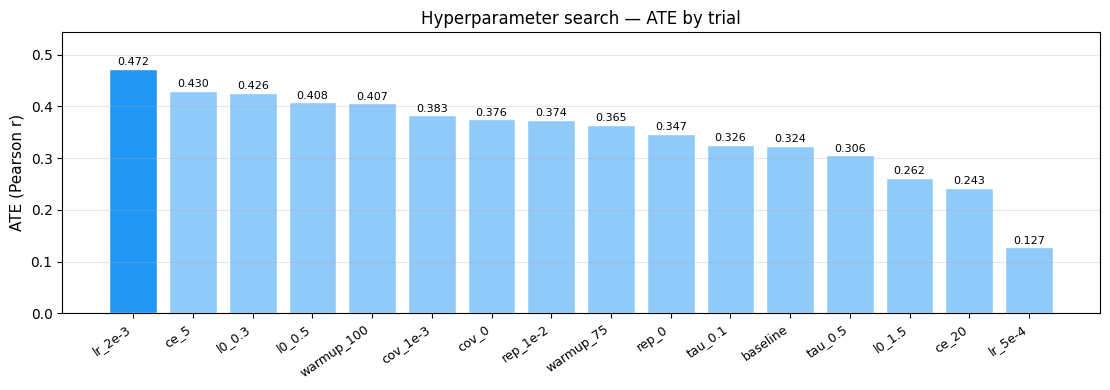

In [7]:
fig, ax = plt.subplots(figsize=(max(8, len(results_df) * 0.7), 4))

colors = ['#2196F3' if i == 0 else '#90CAF9' for i in range(len(results_df))]
bars = ax.bar(results_df['name'], results_df['ATE'], color=colors, edgecolor='white')

for bar, val in zip(bars, results_df['ATE']):
    if np.isfinite(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('ATE (Pearson r)', fontsize=11)
ax.set_title('Hyperparameter search — ATE by trial', fontsize=12)
ax.set_xticklabels(results_df['name'], rotation=35, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, min(1.0, results_df['ATE'].max() * 1.15))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/ate_bar.pdf', bbox_inches='tight')
plt.show()

## Parameter sensitivity

For each swept parameter, hold all others at baseline and plot ATE vs parameter value.  
This gives a single-parameter view of sensitivity.

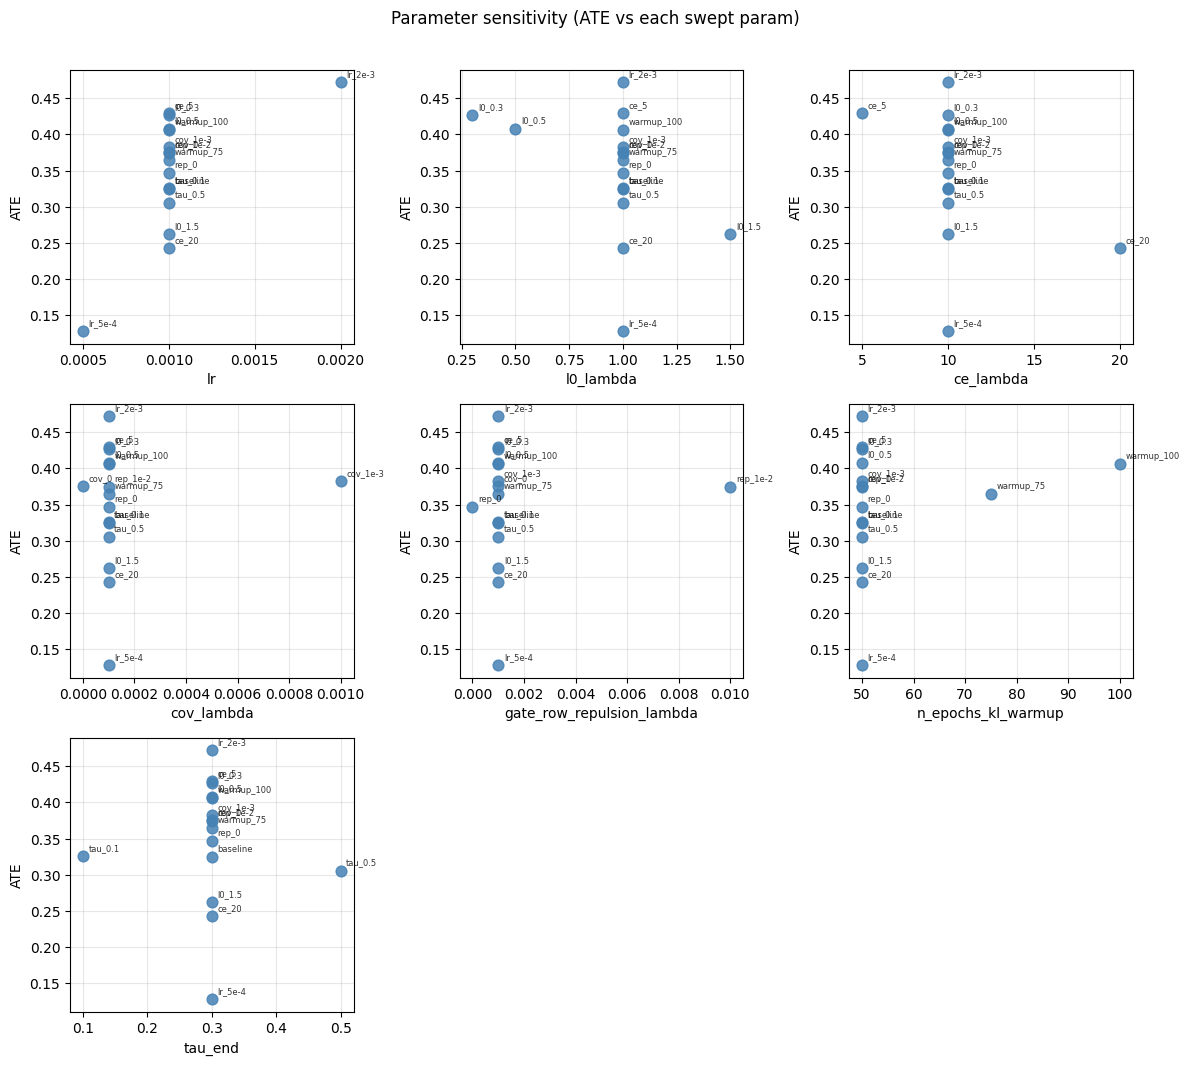

In [8]:
sweep_params = ['lr', 'l0_lambda', 'ce_lambda', 'cov_lambda',
                'gate_row_repulsion_lambda', 'n_epochs_kl_warmup', 'tau_end']
sweep_params = [p for p in sweep_params if p in results_df.columns]

n_params = len(sweep_params)
ncols = 3
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = np.array(axes).flatten()

for ax, param in zip(axes, sweep_params):
    sub = results_df[['name', 'ATE', param]].dropna(subset=[param, 'ATE'])
    x = sub[param].astype(float)
    y = sub['ATE'].astype(float)
    ax.scatter(x, y, s=60, zorder=3, color='steelblue', alpha=0.85)
    for _, row in sub.iterrows():
        ax.annotate(row['name'], (row[param], row['ATE']),
                    textcoords='offset points', xytext=(4, 4), fontsize=6, alpha=0.8)
    ax.set_xlabel(param, fontsize=10)
    ax.set_ylabel('ATE', fontsize=10)
    ax.grid(True, alpha=0.3)
    if x.nunique() > 1 and x.dtype != object:
        ax.set_xscale('log' if x.min() > 0 and x.max() / x.min() > 20 else 'linear')

for ax in axes[n_params:]:
    ax.set_visible(False)

fig.suptitle('Parameter sensitivity (ATE vs each swept param)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/sensitivity.pdf', bbox_inches='tight')
plt.show()

## Gate health per trial

`frac_gates_dead` = fraction of gate probabilities π < 0.05 (collapsed gates).  
A high value indicates L0 over-regularisation.

/var/tmp/ipykernel_4172727/1520220802.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['name'], rotation=35, ha='right', fontsize=9)


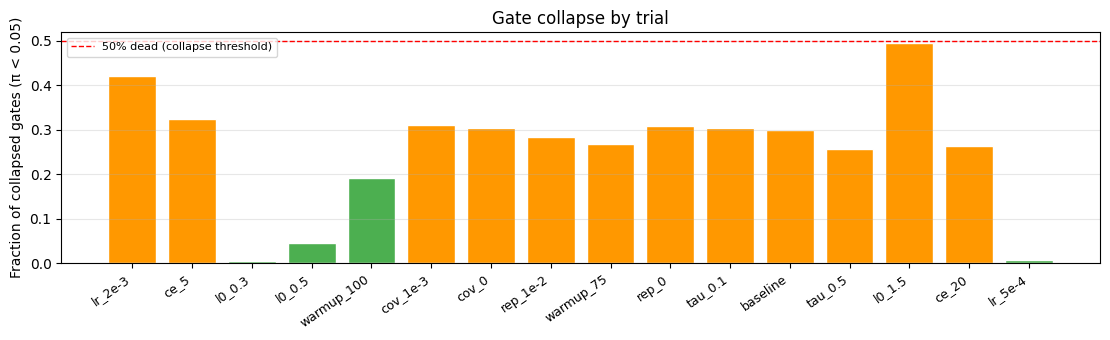

In [9]:
if 'frac_gates_dead' in results_df.columns:
    fig, ax = plt.subplots(figsize=(max(8, len(results_df) * 0.7), 3.5))
    colors = ['#F44336' if v > 0.5 else '#FF9800' if v > 0.2 else '#4CAF50'
              for v in results_df['frac_gates_dead'].fillna(1.0)]
    ax.bar(results_df['name'], results_df['frac_gates_dead'], color=colors, edgecolor='white')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% dead (collapse threshold)')
    ax.set_ylabel('Fraction of collapsed gates (π < 0.05)')
    ax.set_title('Gate collapse by trial')
    ax.set_xticklabels(results_df['name'], rotation=35, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/figures/gate_collapse.pdf', bbox_inches='tight')
    plt.show()

## Best config

Prints the winning hyperparameter set in copy-paste-ready format for `reproducibility.ipynb`.

In [10]:
best = results_df.iloc[0]
print(f'Best trial: {best["name"]}  →  ATE = {best["ATE"]:.4f}\n')

param_keys = ['lr', 'l0_lambda', 'ce_lambda', 'cov_lambda',
              'gate_row_repulsion_lambda', 'n_epochs_kl_warmup', 'tau_end',
              'ntc_lambda', 'pert_lambda', 'shift']
param_keys = [k for k in param_keys if k in best.index]

print('SHERLOCK_KWARGS = {')
for k in param_keys:
    v = best[k]
    if isinstance(v, float) and v == int(v):
        v = int(v)
    print(f'    "{k}": {repr(v)},')
print('}')

print(f'\nNUM_EPOCHS          = {NUM_EPOCHS}')
print(f'LATENT_DIM          = {LATENT_DIM}')
print(f'BATCH_SIZE          = {BATCH_SIZE}')

Best trial: lr_2e-3  →  ATE = 0.4724

SHERLOCK_KWARGS = {
    "lr": np.float64(0.002),
    "l0_lambda": 1,
    "ce_lambda": np.int64(10),
    "cov_lambda": np.float64(0.0001),
    "gate_row_repulsion_lambda": np.float64(0.001),
    "n_epochs_kl_warmup": np.int64(50),
    "tau_end": np.float64(0.3),
    "ntc_lambda": np.float64(1e-05),
    "pert_lambda": np.int64(1),
    "shift": 'linear',
}

NUM_EPOCHS          = 500
LATENT_DIM          = 16
BATCH_SIZE          = 4096


## Rerun best config with debug=True

Shows the ATE trajectory and gate activity over epochs for the winning config.  
The vertical dashed lines mark the end of KL warmup and L0 warmup.

Rerunning best config: lr_2e-3  (debug=True)
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [19:29<00:00,  2.34s/it, ATE=0.4527, CE=3.9977, ELBO=1823.7213, KLw=1.00, R2_ntc=0.9676, R2_p=0.9629, acc=0.204, pi25=0.01, pi99=1.00, tau=0.300]


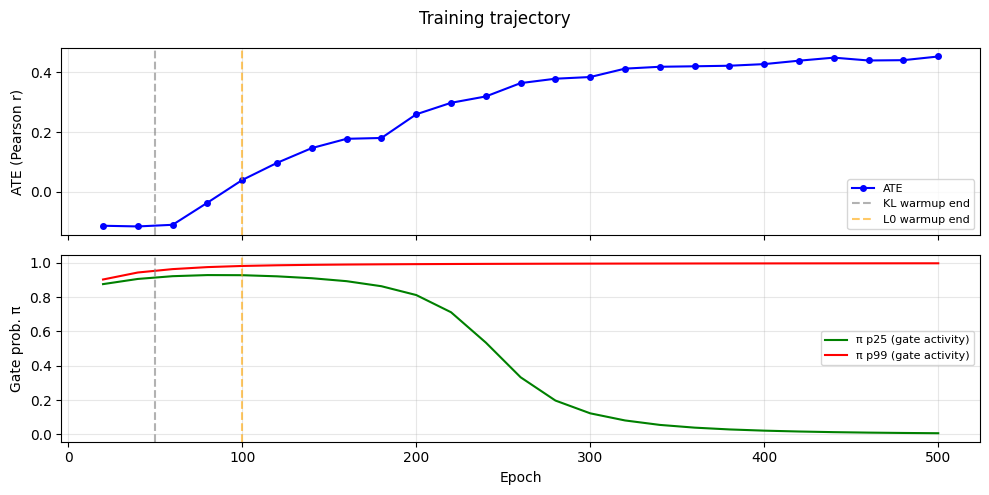

In [11]:
best = results_df.iloc[0]
param_keys = ['lr', 'l0_lambda', 'ce_lambda', 'cov_lambda',
              'gate_row_repulsion_lambda', 'n_epochs_kl_warmup', 'tau_end',
              'ntc_lambda', 'pert_lambda', 'shift']
best_kwargs = {k: best[k] for k in param_keys if k in best.index and pd.notna(best[k])}

print(f'Rerunning best config: {best["name"]}  (debug=True)')

_ = slk.tl.run(
    data,
    model='vae',
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    validate_every=VALIDATE_EVERY,
    device=DEVICE,
    latent_dim=LATENT_DIM,
    patience=PATIENCE,
    seed=0,
    debug=True,
    **best_kwargs,
)

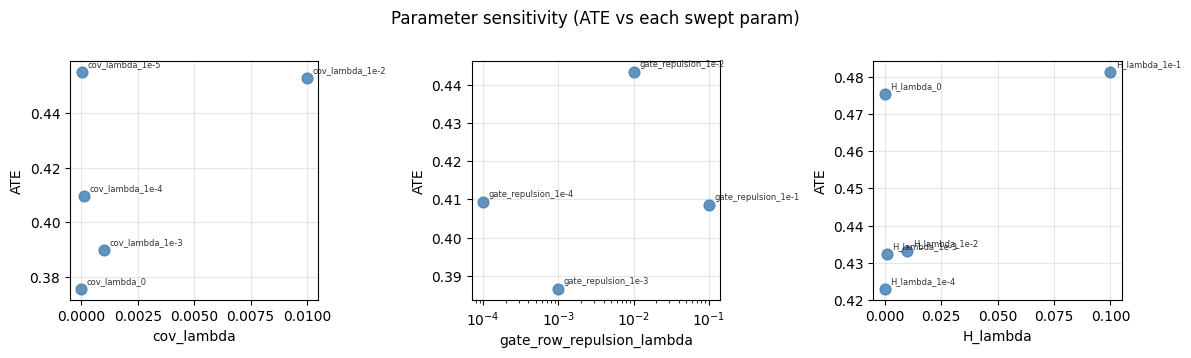

In [12]:
sweep_params = ['lr', 'l0_lambda', 'ce_lambda', 'cov_lambda',
                'gate_row_repulsion_lambda', 'n_epochs_kl_warmup', 'tau_end', 'H_lambda']
sweep_params = [p for p in sweep_params if p in results_df.columns]

n_params = len(sweep_params)
ncols = 3
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = np.array(axes).flatten()

for ax, param in zip(axes, sweep_params):
    sub = results_df[['name', 'ATE', param]].dropna(subset=[param, 'ATE'])
    x = sub[param].astype(float)
    y = sub['ATE'].astype(float)
    ax.scatter(x, y, s=60, zorder=3, color='steelblue', alpha=0.85)
    for _, row in sub.iterrows():
        ax.annotate(row['name'], (row[param], row['ATE']),
                    textcoords='offset points', xytext=(4, 4), fontsize=6, alpha=0.8)
    ax.set_xlabel(param, fontsize=10)
    ax.set_ylabel('ATE', fontsize=10)
    ax.grid(True, alpha=0.3)
    if x.nunique() > 1 and x.dtype != object:
        ax.set_xscale('log' if x.min() > 0 and x.max() / x.min() > 20 else 'linear')

for ax in axes[n_params:]:
    ax.set_visible(False)

fig.suptitle('Parameter sensitivity (ATE vs each swept param)', fontsize=12, y=1.01)
plt.tight_layout()
# plt.savefig(f'{RESULTS_DIR}/figures/sensitivity.pdf', bbox_inches='tight')
plt.show()